In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
print(api_key[:4])

sk-p


In [3]:
import random

known_weather_data = {
    'berlin': 20.0
}

def get_weather(city: str) -> float:
    city = city.strip().lower()

    if city in known_weather_data:
        return known_weather_data[city]

    return round(random.uniform(-5, 35), 1)

## Q1. Define function description

In [4]:
get_weather_tool = {
    "type": "function",
    "name": "get_weather",
    "description": "Get the weather of the city",
    "parameters": {
        "type": "object",
        "properties": {
            "city": {
                "type": "string",
                "description": "Search city for the weather"
            }
        },
        "required": ["city"],
        "additionalProperties": False
    }
}

In [5]:
!wget https://raw.githubusercontent.com/alexeygrigorev/rag-agents-workshop/refs/heads/main/chat_assistant.py

--2025-07-22 10:38:33--  https://raw.githubusercontent.com/alexeygrigorev/rag-agents-workshop/refs/heads/main/chat_assistant.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3485 (3.4K) [text/plain]
Saving to: 'chat_assistant.py'

     0K ...                                                   100%  156K=0.02s

2025-07-22 10:38:34 (156 KB/s) - 'chat_assistant.py' saved [3485/3485]



In [6]:
import chat_assistant

tools = chat_assistant.Tools()
tools.add_tool(get_weather, get_weather_tool)

tools.get_tools()


[{'type': 'function',
  'name': 'get_weather',
  'description': 'Get the weather of the city',
  'parameters': {'type': 'object',
   'properties': {'city': {'type': 'string',
     'description': 'Search city for the weather'}},
   'required': ['city'],
   'additionalProperties': False}}]

In [8]:
from openai import OpenAI
client = OpenAI()

In [9]:
developer_prompt = """
You're a helpful assistant. 
You're given a city and your task is to get the weather of the city.

Use knowledge base if your own knowledge is not sufficient to answer the question.

At the end of each response, ask the user a follow up question based on your answer.
""".strip()

chat_interface = chat_assistant.ChatInterface()

chat = chat_assistant.ChatAssistant(
    tools=tools,
    developer_prompt=developer_prompt,
    chat_interface=chat_interface,
    client=client
)

In [10]:
chat.run()

You: what is the weather at berlin?


You: exit


You: quit


You: stop


Chat ended.


## Q2. Adding another tool

In [11]:
def set_weather(city: str, temp: float) -> None:
    city = city.strip().lower()
    known_weather_data[city] = temp
    return 'OK'

In [15]:
set_weather_tool = {
    "type": "function",
    "name": "set_weather",
    "description": "Add the weather of the city to database",
    "parameters": {
        "type": "object",
        "properties": {
            "city": {
                "type": "string",
                "description": "The city to be added to database"
            },
            "temp": {
                "type": "number",
                "description": "The temperature to be added to database",
            }
        },
        "required": ["city", "temp"],
        "additionalProperties": False
    }
}

In [16]:

tools.add_tool(set_weather, set_weather_tool)

tools.get_tools()

[{'type': 'function',
  'name': 'get_weather',
  'description': 'Get the weather of the city',
  'parameters': {'type': 'object',
   'properties': {'city': {'type': 'string',
     'description': 'Search city for the weather'}},
   'required': ['city'],
   'additionalProperties': False}},
 {'type': 'function',
  'name': 'set_weather',
  'description': 'Add the weather of the city to database',
  'parameters': {'type': 'object',
   'properties': {'city': {'type': 'string',
     'description': 'The city to be added to database'},
    'temp': {'type': 'number',
     'description': 'The temperature to be added to database'}},
   'required': ['city', 'temp'],
   'additionalProperties': False}}]

In [17]:
chat.run()

You: the weather at new york is 25*c


You: stop


Chat ended.


## Q3. Install FastMCP

In [18]:
pip install fastmcp

  Using cached pydantic-2.11.7-py3-none-any.whl.metadata (67 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pydantic_core-2.33.2-cp312-cp312-win_amd64.whl.metadata (6.9 kB)
Using cached pydantic-2.11.7-py3-none-any.whl (444 kB)
Using cached pydantic_core-2.33.2-cp312-cp312-win_amd64.whl (2.0 MB)
   ---------------------------------------- 0.0/587.4 kB ? eta -:--:--
   --------------------------------------- 587.4/587.4 kB 10.5 MB/s eta 0:00:00
  Created wheel for pyperclip: filename=pyperclip-1.9.0-py3-none-any.whl size=11117 sha256=172ab0a079461312d622f0f3f7165ff6f82ea87021967a628dc701db4b5199ca
  Stored in directory: c:\users\crab\appdata\local\pip\cache\wheels\e0\e8\fc\8ab8aa326e33bc066

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.6.17 which is incompatible.


In [ ]:
# weather_server.py
from fastmcp import FastMCP

mcp = FastMCP("Demo 🚀")

import random

known_weather_data = {
    'berlin': 20.0
} 

@mcp.tool 
def get_weather(city: str) -> float:
    """
    Retrieves the temperature for a specified city.

    Parameters:
        city (str): The name of the city for which to retrieve weather data.

    Returns:
        float: The temperature associated with the city.
    """
    city = city.strip().lower()

    if city in known_weather_data:
        return known_weather_data[city]

    return round(random.uniform(-5, 35), 1)


@mcp.tool 
def set_weather(city: str, temp: float) -> None:
    """
    Sets the temperature for a specified city.

    Parameters:
        city (str): The name of the city for which to set the weather data.
        temp (float): The temperature to associate with the city.

    Returns:
        str: A confirmation string 'OK' indicating successful update.
    """
    city = city.strip().lower()
    known_weather_data[city] = temp
    return 'OK'

if __name__ == "__main__":
    mcp.run()

In [2]:
pip list | grep fastmcp

fastmcp                                  2.10.6
Note: you may need to restart the kernel to use updated packages.


## Q4. Simple MCP Server

In [ ]:
# weather_server.py
from fastmcp import FastMCP

mcp = FastMCP("Demo 🚀")

@mcp.tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

if __name__ == "__main__":
    await mcp.run_http_async(transport="streamable-http", port=8001)


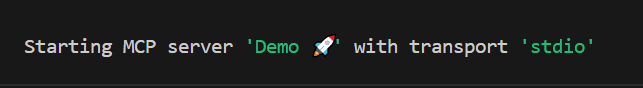

## Q5. Protocol

Input `
{"jsonrpc": "2.0", "id": 3, "method": "tools/call", "params": {"name": "get_weather", "arguments": {"city":"berlin"}}}`

Output `
{"jsonrpc":"2.0","id":3,"result":{"content":[{"type":"text","text":"20.0"}],"structuredContent":{"result":20.0},"isError":false}} `

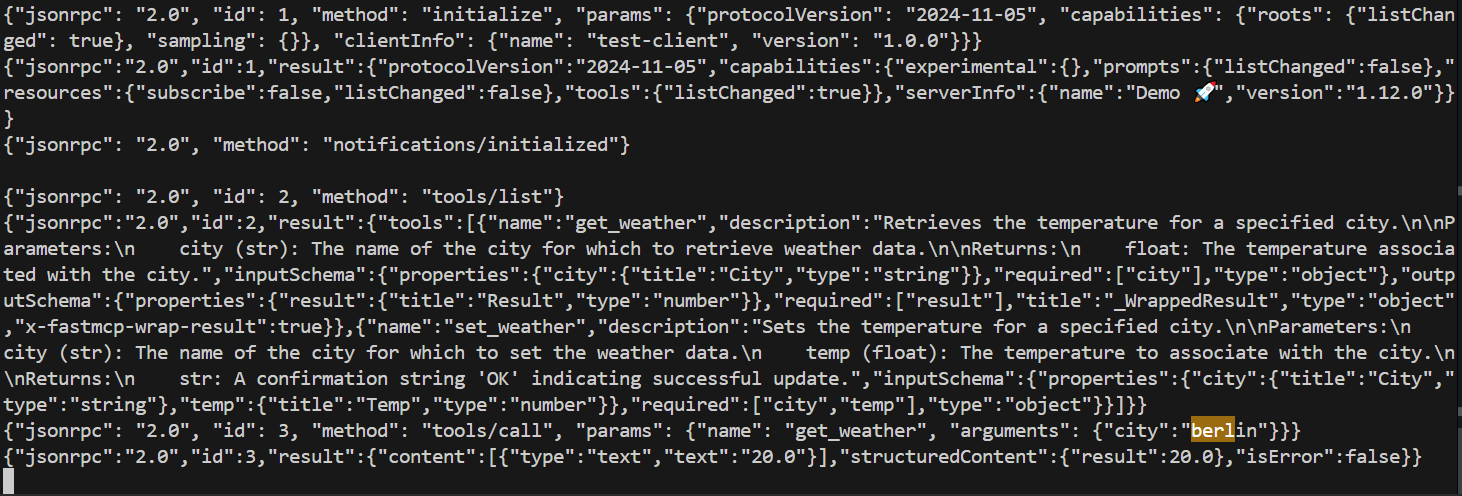

## Q6. Client

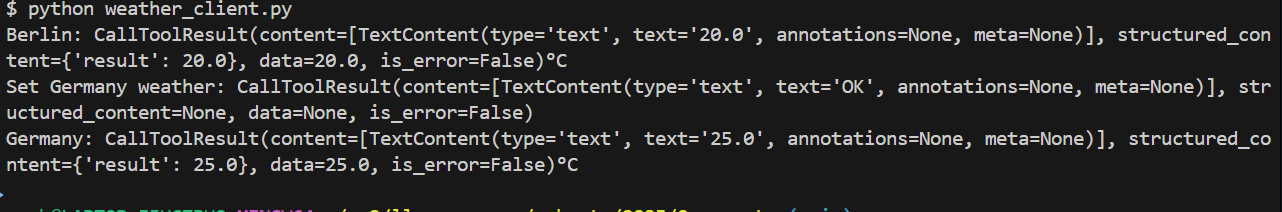